In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

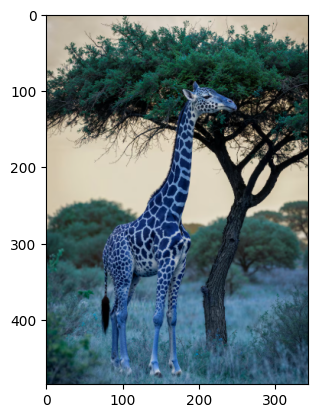

In [2]:
image = cv2.imread("./assets/giraffe.png")
plt.imshow(image)

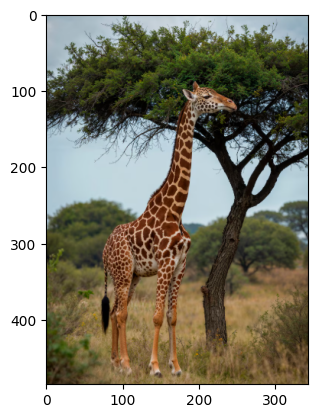

In [4]:
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)

### Perspective Transformation

In [6]:
# (height, width, channels)
rgb_image.shape

(485, 344, 3)

In [ ]:
# [50, 50]: উপরের বাম কোণ থেকে 50 পিক্সেল ডান এবং নিচে

# [cols-50, 50]: উপরের ডান কোণে, কিন্তু 50 পিক্সেল বামে

# [50, rows-50]: নিচের বাম কোণে, কিন্তু 50 পিক্সেল উপরে

# [cols-50, rows-50]: নিচের ডান কোণে, কিন্তু 50 পিক্সেল বামে এবং 50 পিক্সেল উপরে
# input_points = np.float32([[50, 50], [cols-50, 50], [50, rows-50], [cols-50, rows-50]])


# [10, 100]: প্রায় উপরের বাম কোণে

# [cols-100, 50]: প্রায় উপরের ডান কোণে

# [100, rows-10]: প্রায় নিচের বাম কোণে

# [cols-50, rows-100]: প্রায় নিচের ডান কোণে
# output_points = np.float32([[10, 100], [cols-100, 50], [100, rows-10], [cols-50, rows-100]])

In [8]:
rows, cols, _ = rgb_image.shape

input_points = np.float32([[50, 50], [cols-50, 50], [50, rows-50], [cols-50, rows-50]])
output_points = np.float32([[10, 100], [cols-100, 50], [100, rows-10], [cols-50, rows-100]])

In [9]:
M = cv2.getPerspectiveTransform(input_points, output_points)
M

array([[ 1.18757819e+00,  2.92402303e-01, -6.34191988e+01],
       [-1.81357993e-01,  1.24464059e+00,  5.26341266e+01],
       [ 7.08834267e-04,  4.50817038e-04,  1.00000000e+00]])

(np.float64(-0.5), np.float64(343.5), np.float64(484.5), np.float64(-0.5))

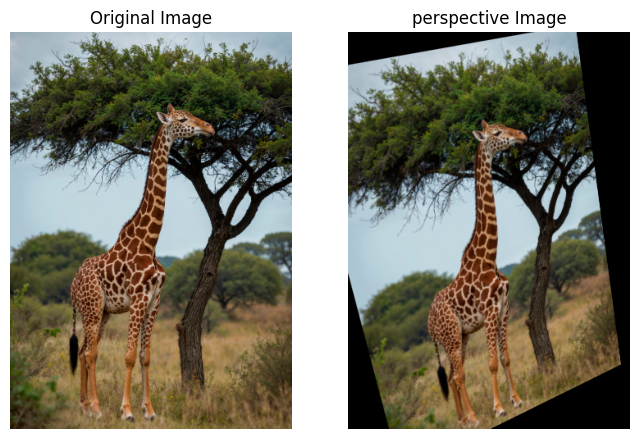

In [14]:
perspective_image = cv2.warpPerspective(rgb_image, M, (cols, rows))

plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(perspective_image)
plt.title("perspective Image")
plt.axis("off")

### Affine Transformation

(np.float64(-0.5), np.float64(343.5), np.float64(484.5), np.float64(-0.5))

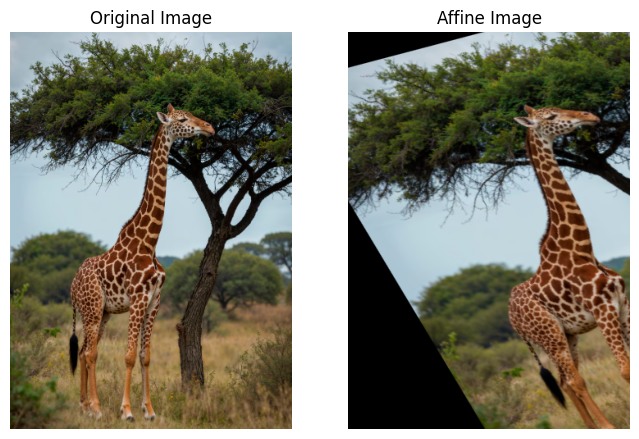

In [16]:
input_points = np.float32([ [50, 50], [200, 50], [50, 200] ])
output_points = np.float32([ [10, 100], [200, 50], [100, 250] ])


M = cv2.getAffineTransform(input_points, output_points)

affine_image = cv2.warpAffine(rgb_image, M, (cols, rows))



plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(affine_image)
plt.title("Affine Image")
plt.axis("off")



### Rotation

(np.float64(-0.5), np.float64(343.5), np.float64(484.5), np.float64(-0.5))

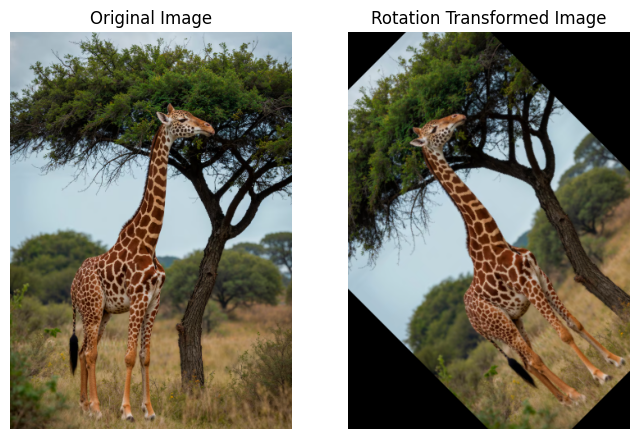

In [17]:
angle = 45
center = (cols // 2, rows // 2)
scale = 1.0

M = cv2.getRotationMatrix2D(center, angle, scale)

rotation_image = cv2.warpAffine(rgb_image, M, (cols, rows))

plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(rotation_image)
plt.title("Rotation Transformed Image")
plt.axis("off")


### Shearing

(np.float64(-0.5), np.float64(687.5), np.float64(484.5), np.float64(-0.5))

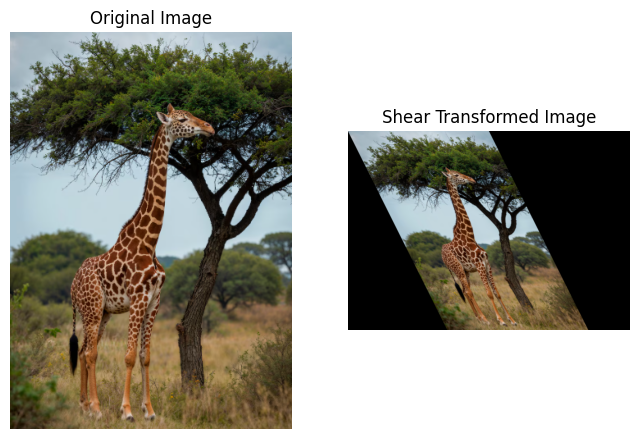

In [23]:
angle = 45
center = (cols // 2, rows // 2)
scale = 1.0

shear_x, shear_y = 0.5, 0

M = np.float32([ [1, shear_x, 0], [shear_y, 1, 0] ])

 

shear_image = cv2.warpAffine(rgb_image, M, (cols*2, rows))

plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(shear_image)
plt.title("Shear Transformed Image")
plt.axis("off")


### Translate

(np.float64(-0.5), np.float64(343.5), np.float64(484.5), np.float64(-0.5))

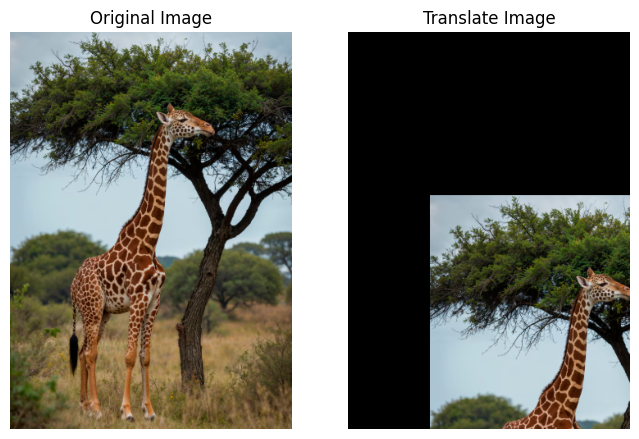

In [24]:

tx, ty = 100, 200


M = np.float32([ [1, 0, tx], [0, 1, ty] ])


translate_image = cv2.warpAffine(rgb_image, M, (cols, rows))

plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(translate_image)
plt.title("Translate Image")
plt.axis("off")
